# Model Comparison: Base vs Instruct vs Reasoning

Analysis of how base, instruct, and reasoning models differ in their alignment with survey-measured partisan polarization.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## 1. Load Results

In [2]:
# Load most recent results for each model
import glob
import re
from collections import defaultdict

results_dir = Path('../results')

# Find all per-model checkpoint files (not aggregate checkpoints)
# Pattern: comparison_{model_name}_{timestamp}.pkl
per_model_files = glob.glob(str(results_dir / 'comparison_*.pkl'))
per_model_files = [f for f in per_model_files if '_checkpoint.pkl' not in f and '_detail_' not in f 
                   and '_correlations_' not in f and '_filtered_' not in f 
                   and '_bar_' not in f and '_scatter_' not in f]

print(f"Found {len(per_model_files)} per-model checkpoint file(s)")

# Group by model name, keep most recent for each
model_files = defaultdict(list)
for f in per_model_files:
    fname = Path(f).name
    # Extract model name and timestamp: comparison_{model_name}_{timestamp}.pkl
    match = re.match(r'comparison_(.+?)_(\d{8}_\d{6})\.pkl', fname)
    if match:
        model_name = match.group(1)
        timestamp = match.group(2)
        model_files[model_name].append((timestamp, f))

# Pick most recent file for each model
selected_files = {}
for model_name, file_list in model_files.items():
    file_list.sort(key=lambda x: x[0], reverse=True)  # Sort by timestamp, newest first
    timestamp, filepath = file_list[0]
    selected_files[model_name] = (timestamp, filepath)
    if len(file_list) > 1:
        print(f"  {model_name}: Using {timestamp} (found {len(file_list)} versions)")

print(f"\nLoading most recent results for {len(selected_files)} models:")

# Load selected files
dfs = []
for model_name, (timestamp, filepath) in sorted(selected_files.items()):
    df_model = pd.read_pickle(filepath)
    print(f"  {model_name:40s} ({timestamp}): {len(df_model)} topics")
    dfs.append(df_model)

df = pd.concat(dfs, ignore_index=True)

print(f"\nCombined dataset:")
print(f"  Total rows: {len(df)}")
print(f"  Models: {df['model_name'].nunique()}")
print(f"  Families: {sorted(df['family'].unique())}")
print(f"  Model types: {sorted(df['model_type'].unique())}")
print(f"  Categories: {sorted(df['category'].unique())}")
print()
print("Model breakdown:")
breakdown = df.groupby(['family', 'model_type', 'model_name']).size().reset_index(name='n_topics')
for _, row in breakdown.iterrows():
    print(f"  {row['family']:15s} {row['model_type']:10s} {row['model_name']:40s} {row['n_topics']:3d} topics")

Found 44 per-model checkpoint file(s)
  Llama-3.1-8B_instruct: Using 20260215_120317 (found 3 versions)
  Qwen3-4B_base: Using 20260215_120317 (found 4 versions)
  Qwen2.5-7B_base: Using 20260215_120317 (found 4 versions)
  Gemma-2-9b_base: Using 20260215_120317 (found 4 versions)
  Gemma-2-9b_instruct: Using 20260215_120317 (found 3 versions)
  Qwen2.5-7B_instruct: Using 20260215_120317 (found 3 versions)
  SmolLM3-3B_base: Using 20260215_120317 (found 4 versions)
  Qwen3-4B_instruct: Using 20260215_120317 (found 3 versions)
  Llama-3.1-8B_reasoning: Using 20260215_120317 (found 3 versions)
  Llama-3.1-8B_base: Using 20260215_120317 (found 4 versions)
  Qwen3-4B_reasoning: Using 20260215_120317 (found 3 versions)
  SmolLM3-3B_reasoning: Using 20260215_120317 (found 3 versions)
  SmolLM3-3B_instruct: Using 20260215_120317 (found 3 versions)

Loading most recent results for 13 models:
  Gemma-2-9b_base                          (20260215_120317): 209 topics
  Gemma-2-9b_instruct         

## 2. Load Polarization Data

In [3]:
import os

# Load polarization data directly (avoiding transformers import conflict)
def load_polarization_data(csv_path):
    """Load polarization data from CSV."""
    df = pd.read_csv(csv_path)
    return df

# Construct absolute path to data directory
base_dir = Path(os.path.abspath('..')).parent  # Go to gss_polarization/
pol_dir = base_dir / 'data' / 'polarization'

pol_pub = load_polarization_data(str(pol_dir / 'public_issues_polarization.csv'))
pol_priv = load_polarization_data(str(pol_dir / 'private_life_polarization.csv'))

# Filter by minimum counts (same as script)
pol_pub = pol_pub[(pol_pub['n_dem'] >= 100) & (pol_pub['n_rep'] >= 100) & (pol_pub['n_total'] >= 200)]
pol_priv = pol_priv[(pol_priv['n_dem'] >= 100) & (pol_priv['n_rep'] >= 100) & (pol_priv['n_total'] >= 200)]

print(f"Data directory: {pol_dir}")
print(f"Public issues: {len(pol_pub)} topics")
print(f"Private life: {len(pol_priv)} topics")

Data directory: /project/jevans/maxzhuyt/gss_polarization/data/polarization
Public issues: 134 topics
Private life: 87 topics


## 3. Compute Correlations

Calculate Pearson r and Spearman rho for each model × category.

In [4]:
# Excluded topics (matching run_gss_pca.py defaults)
EXCLUDE_PUBLIC = ['hubbywk1', 'racdif1', 'racdif2', 'racdif3', 'racdif4', 
                  'workwhts', 'wlthwhts', 'intlwhts']
EXCLUDE_PRIVATE = ['reborn', 'marwht', 'helpful', 'helpfulnv', 'helpfulv']

pol_data = {
    'public_issues': pol_pub,
    'private_life': pol_priv,
}

exclude_map = {
    'public_issues': set(EXCLUDE_PUBLIC),
    'private_life': set(EXCLUDE_PRIVATE),
}

# Compute correlations for PCA-15, mean centroid
rows = []
for (model_name, model_type, family, cat), df_group in df.groupby(
    ['model_name', 'model_type', 'family', 'category']
):
    excl = exclude_map[cat]
    df_filt = df_group[~df_group['Topic'].isin(excl)].copy()
    
    pol_df = pol_data[cat]
    pol_filt = pol_df[~pol_df['variable'].isin(excl)]
    
    df_merged = df_filt.merge(
        pol_filt[['variable', 'polarization']].rename(
            columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
        ),
        on='Topic', how='inner'
    )
    
    if len(df_merged) < 5:
        continue
    
    col = 'Avg_Mahal_PCA15'
    r, r_p = pearsonr(df_merged[col], df_merged['GSS_Polarization'])
    rho, rho_p = spearmanr(df_merged[col], df_merged['GSS_Polarization'])
    
    rows.append({
        'family': family,
        'model_name': model_name,
        'model_type': model_type,
        'category': cat,
        'n_topics': len(df_merged),
        'pearson_r': round(r, 4),
        'pearson_p': round(r_p, 4),
        'spearman_rho': round(rho, 4),
        'spearman_p': round(rho_p, 4),
    })

df_corr = pd.DataFrame(rows)
print(df_corr.to_string(index=False))

      family             model_name model_type      category  n_topics  pearson_r  pearson_p  spearman_rho  spearman_p
  Gemma-2-9b        Gemma-2-9b_base       base  private_life        72     0.3562     0.0021        0.3405      0.0034
  Gemma-2-9b        Gemma-2-9b_base       base public_issues       126     0.5524     0.0000        0.5554      0.0000
  Gemma-2-9b    Gemma-2-9b_instruct   instruct  private_life        72     0.6321     0.0000        0.5265      0.0000
  Gemma-2-9b    Gemma-2-9b_instruct   instruct public_issues       126     0.6478     0.0000        0.6347      0.0000
Llama-3.1-8B      Llama-3.1-8B_base       base  private_life        72     0.3321     0.0044        0.3364      0.0039
Llama-3.1-8B      Llama-3.1-8B_base       base public_issues       126     0.4563     0.0000        0.4689      0.0000
Llama-3.1-8B  Llama-3.1-8B_instruct   instruct  private_life        72     0.5460     0.0000        0.4476      0.0001
Llama-3.1-8B  Llama-3.1-8B_instruct   instruct p

## 4. Grouped Bar Chart: Base vs Instruct vs Reasoning

Show individual models side-by-side, grouped by family and model type.

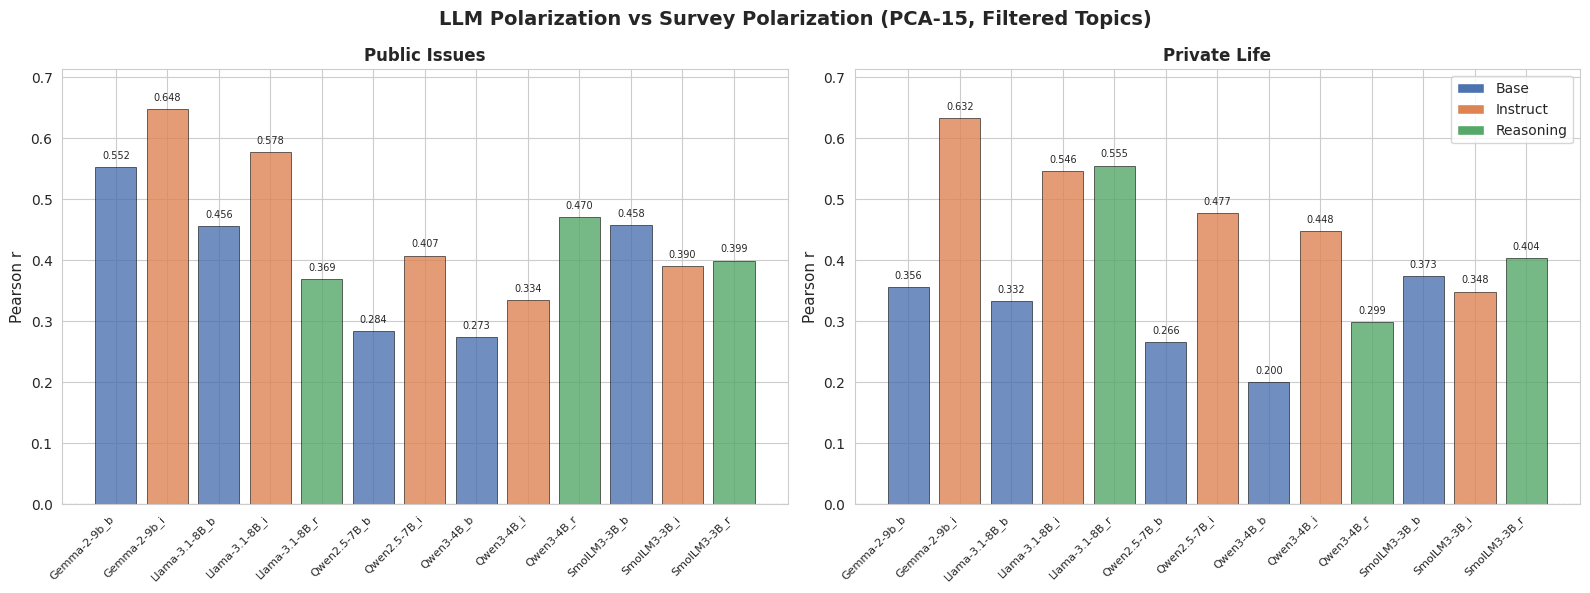

In [5]:
# Prepare data for plotting
df_pub = df_corr[df_corr['category'] == 'public_issues'].copy()
df_priv = df_corr[df_corr['category'] == 'private_life'].copy()

# Add short labels
df_pub['short_label'] = df_pub['family'] + '_' + df_pub['model_type'].str[0]
df_priv['short_label'] = df_priv['family'] + '_' + df_priv['model_type'].str[0]

# Color map
type_colors = {'base': '#4C72B0', 'instruct': '#DD8452', 'reasoning': '#55A868'}
df_pub['color'] = df_pub['model_type'].map(type_colors)
df_priv['color'] = df_priv['model_type'].map(type_colors)

# Sort by family then type
type_order = {'base': 0, 'instruct': 1, 'reasoning': 2}
df_pub['sort_key'] = df_pub['family'] + df_pub['model_type'].map(type_order).astype(str)
df_priv['sort_key'] = df_priv['family'] + df_priv['model_type'].map(type_order).astype(str)
df_pub = df_pub.sort_values('sort_key')
df_priv = df_priv.sort_values('sort_key')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Public issues
ax = axes[0]
x = np.arange(len(df_pub))
bars = ax.bar(x, df_pub['pearson_r'], color=df_pub['color'], alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_pub['short_label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title('Public Issues', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylim(0, max(df_pub['pearson_r'].max(), df_priv['pearson_r'].max()) * 1.1)

# Add value labels on bars
for i, (idx, row) in enumerate(df_pub.iterrows()):
    ax.text(i, row['pearson_r'] + 0.01, f"{row['pearson_r']:.3f}", 
            ha='center', va='bottom', fontsize=7)

# Private life
ax = axes[1]
x = np.arange(len(df_priv))
bars = ax.bar(x, df_priv['pearson_r'], color=df_priv['color'], alpha=0.8, edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(df_priv['short_label'], rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Pearson r', fontsize=11)
ax.set_title('Private Life', fontsize=12, fontweight='bold')
ax.axhline(y=0, color='gray', linewidth=0.8, linestyle='--')
ax.set_ylim(0, max(df_pub['pearson_r'].max(), df_priv['pearson_r'].max()) * 1.1)

# Add value labels on bars
for i, (idx, row) in enumerate(df_priv.iterrows()):
    ax.text(i, row['pearson_r'] + 0.01, f"{row['pearson_r']:.3f}", 
            ha='center', va='bottom', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=type_colors['base'], label='Base'),
    Patch(facecolor=type_colors['instruct'], label='Instruct'),
    Patch(facecolor=type_colors['reasoning'], label='Reasoning'),
]
axes[1].legend(handles=legend_elements, loc='upper right', fontsize=10)

fig.suptitle('LLM Polarization vs Survey Polarization (PCA-15, Filtered Topics)', 
             fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout()
plt.savefig('../results/comparison_bar_individual_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Family-Level Comparison

Group by family to see patterns across base/instruct/reasoning within each family.

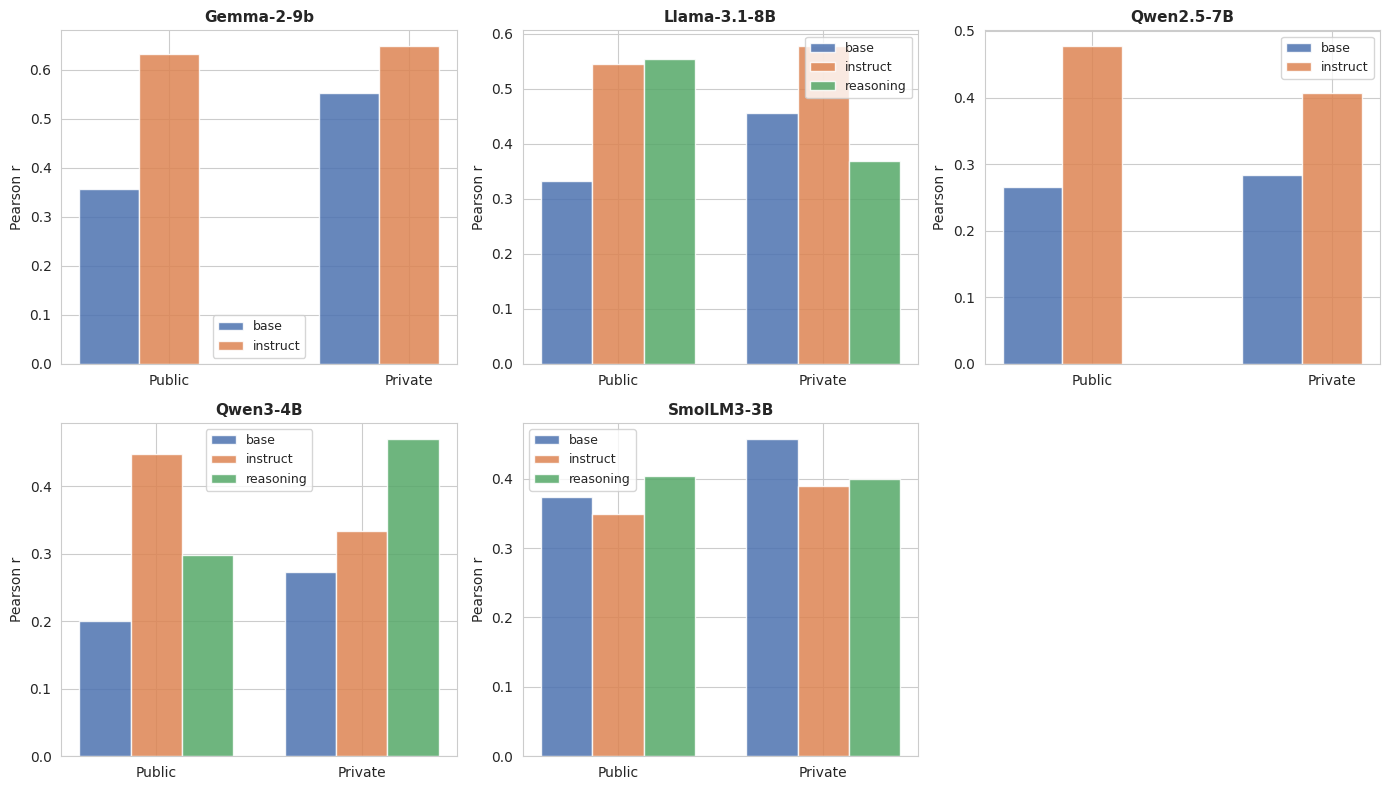

In [6]:
families = sorted(df_corr['family'].unique())
n_families = len(families)
n_cols = 3
n_rows = (n_families + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows))
axes = axes.flatten() if n_families > 1 else [axes]

type_order = ['base', 'instruct', 'reasoning']

for i, fam in enumerate(families):
    ax = axes[i]
    df_fam = df_corr[df_corr['family'] == fam]
    
    # Pivot for grouped bar
    pivot = df_fam.pivot_table(
        index='category', 
        columns='model_type', 
        values='pearson_r'
    )
    pivot = pivot[[t for t in type_order if t in pivot.columns]]
    
    x = np.arange(len(pivot))
    width = 0.25
    
    for j, mtype in enumerate(pivot.columns):
        ax.bar(x + j * width, pivot[mtype], width, 
               label=mtype, color=type_colors[mtype], alpha=0.85)
    
    ax.set_xticks(x + width)
    ax.set_xticklabels(['Public', 'Private'], fontsize=10)
    ax.set_ylabel('Pearson r', fontsize=10)
    ax.set_title(fam, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')

# Hide extra subplots
for i in range(n_families, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('../results/comparison_by_family.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Table

In [7]:
# Create summary table: rows = families, columns = model types, values = avg(public + private)
df_avg = df_corr.groupby(['family', 'model_type'])['pearson_r'].mean().reset_index()
summary = df_avg.pivot(index='family', columns='model_type', values='pearson_r')
summary = summary[[t for t in type_order if t in summary.columns]]

print("\nAverage correlation (across public + private):")
print(summary.to_string())

# Add difference columns
if 'instruct' in summary.columns and 'base' in summary.columns:
    summary['instruct - base'] = summary['instruct'] - summary['base']
if 'reasoning' in summary.columns and 'instruct' in summary.columns:
    summary['reasoning - instruct'] = summary['reasoning'] - summary['instruct']

print("\nWith differences:")
print(summary.to_string())


Average correlation (across public + private):
model_type      base  instruct  reasoning
family                                   
Gemma-2-9b    0.4543   0.63995        NaN
Llama-3.1-8B  0.3942   0.56175    0.46215
Qwen2.5-7B    0.2746   0.44220        NaN
Qwen3-4B      0.2365   0.39095    0.38450
SmolLM3-3B    0.4154   0.36895    0.40135

With differences:
model_type      base  instruct  reasoning  instruct - base  reasoning - instruct
family                                                                          
Gemma-2-9b    0.4543   0.63995        NaN          0.18565                   NaN
Llama-3.1-8B  0.3942   0.56175    0.46215          0.16755              -0.09960
Qwen2.5-7B    0.2746   0.44220        NaN          0.16760                   NaN
Qwen3-4B      0.2365   0.39095    0.38450          0.15445              -0.00645
SmolLM3-3B    0.4154   0.36895    0.40135         -0.04645               0.03240


## 7. Per-Category Summary

Show public vs private separately.

In [8]:
for cat_name in ['public_issues', 'private_life']:
    print(f"\n{'='*60}")
    print(f"{cat_name.upper()}")
    print(f"{'='*60}")
    
    df_cat = df_corr[df_corr['category'] == cat_name]
    pivot = df_cat.pivot(index='family', columns='model_type', values='pearson_r')
    pivot = pivot[[t for t in type_order if t in pivot.columns]]
    
    if 'instruct' in pivot.columns and 'base' in pivot.columns:
        pivot['instruct - base'] = pivot['instruct'] - pivot['base']
    if 'reasoning' in pivot.columns and 'instruct' in pivot.columns:
        pivot['reasoning - instruct'] = pivot['reasoning'] - pivot['instruct']
    
    print(pivot.to_string())


PUBLIC_ISSUES
model_type      base  instruct  reasoning  instruct - base  reasoning - instruct
family                                                                          
Gemma-2-9b    0.5524    0.6478        NaN           0.0954                   NaN
Llama-3.1-8B  0.4563    0.5775     0.3694           0.1212               -0.2081
Qwen2.5-7B    0.2836    0.4073        NaN           0.1237                   NaN
Qwen3-4B      0.2733    0.3340     0.4704           0.0607                0.1364
SmolLM3-3B    0.4576    0.3895     0.3991          -0.0681                0.0096

PRIVATE_LIFE
model_type      base  instruct  reasoning  instruct - base  reasoning - instruct
family                                                                          
Gemma-2-9b    0.3562    0.6321        NaN           0.2759                   NaN
Llama-3.1-8B  0.3321    0.5460     0.5549           0.2139                0.0089
Qwen2.5-7B    0.2656    0.4771        NaN           0.2115                   NaN

## 8. PCA Dimension Comparison

How do correlations between LLM Mahalanobis distance and GSS polarization change across different numbers of principal components (1, 3, 5, 10, 15)?

Shows every model individually — no averaging, since N is small.

In [9]:
# Detect available PCA dimensions from the data
pca_dims = sorted([
    int(c.replace('Avg_Mahal_PCA', ''))
    for c in df.columns
    if c.startswith('Avg_Mahal_PCA') and c.replace('Avg_Mahal_PCA', '').isdigit()
])
print(f"Available PCA dimensions: {pca_dims}")

# Compute Pearson r for every model × category × PCA dimension
rows_pca = []
for (model_name, model_type, family, cat), df_group in df.groupby(
    ['model_name', 'model_type', 'family', 'category']
):
    excl = exclude_map[cat]
    df_filt = df_group[~df_group['Topic'].isin(excl)].copy()
    
    pol_df = pol_data[cat]
    pol_filt = pol_df[~pol_df['variable'].isin(excl)]
    
    df_merged = df_filt.merge(
        pol_filt[['variable', 'polarization']].rename(
            columns={'variable': 'Topic', 'polarization': 'GSS_Polarization'}
        ),
        on='Topic', how='inner'
    )
    
    if len(df_merged) < 5:
        continue
    
    row = {
        'family': family,
        'model': model_name,
        'type': model_type,
        'category': cat,
        'n': len(df_merged),
    }
    for dim in pca_dims:
        col = f'Avg_Mahal_PCA{dim}'
        if col in df_merged.columns:
            r, _ = pearsonr(df_merged[col], df_merged['GSS_Polarization'])
            row[f'PCA{dim}'] = round(r, 3)
        else:
            row[f'PCA{dim}'] = np.nan
    rows_pca.append(row)

df_pca = pd.DataFrame(rows_pca)

# Display tables per category
pca_cols = [f'PCA{d}' for d in pca_dims]

for cat_name, cat_label in [('public_issues', 'PUBLIC ISSUES'), ('private_life', 'PRIVATE LIFE')]:
    print(f"\n{'='*80}")
    print(f"  {cat_label} — Pearson r (LLM Mahalanobis vs GSS Polarization) by PCA Dimension")
    print(f"{'='*80}")
    
    df_cat = df_pca[df_pca['category'] == cat_name].copy()
    df_cat = df_cat.sort_values(['family', 'type'])
    
    display_cols = ['family', 'model', 'type', 'n'] + pca_cols
    print(df_cat[display_cols].to_string(index=False))
    
    # Highlight: which PCA dim gives the highest r for each model?
    print(f"\n  Best PCA dim per model:")
    for _, row in df_cat.iterrows():
        vals = {d: row[f'PCA{d}'] for d in pca_dims if not np.isnan(row[f'PCA{d}'])}
        if vals:
            best_dim = max(vals, key=vals.get)
            print(f"    {row['model']:40s} → PCA{best_dim} (r={vals[best_dim]:.3f})")

Available PCA dimensions: [1, 3, 5, 10, 15]

  PUBLIC ISSUES — Pearson r (LLM Mahalanobis vs GSS Polarization) by PCA Dimension
      family                  model      type   n  PCA1  PCA3  PCA5  PCA10  PCA15
  Gemma-2-9b        Gemma-2-9b_base      base 126 0.416 0.397 0.441  0.525  0.552
  Gemma-2-9b    Gemma-2-9b_instruct  instruct 126 0.532 0.632 0.638  0.646  0.648
Llama-3.1-8B      Llama-3.1-8B_base      base 126 0.306 0.306 0.333  0.423  0.456
Llama-3.1-8B  Llama-3.1-8B_instruct  instruct 126 0.368 0.461 0.506  0.560  0.578
Llama-3.1-8B Llama-3.1-8B_reasoning reasoning 126 0.332 0.326 0.330  0.363  0.369
  Qwen2.5-7B        Qwen2.5-7B_base      base 126 0.038 0.066 0.159  0.226  0.284
  Qwen2.5-7B    Qwen2.5-7B_instruct  instruct 126 0.330 0.360 0.402  0.419  0.407
    Qwen3-4B          Qwen3-4B_base      base 126 0.081 0.088 0.180  0.269  0.273
    Qwen3-4B      Qwen3-4B_instruct  instruct 126 0.101 0.331 0.372  0.361  0.334
    Qwen3-4B     Qwen3-4B_reasoning reasoning 126 0.

Plotting 5 families...
  Family 1/5: Gemma-2-9b
  Family 2/5: Llama-3.1-8B
  Family 3/5: Qwen2.5-7B
  Family 4/5: Qwen3-4B
  Family 5/5: SmolLM3-3B


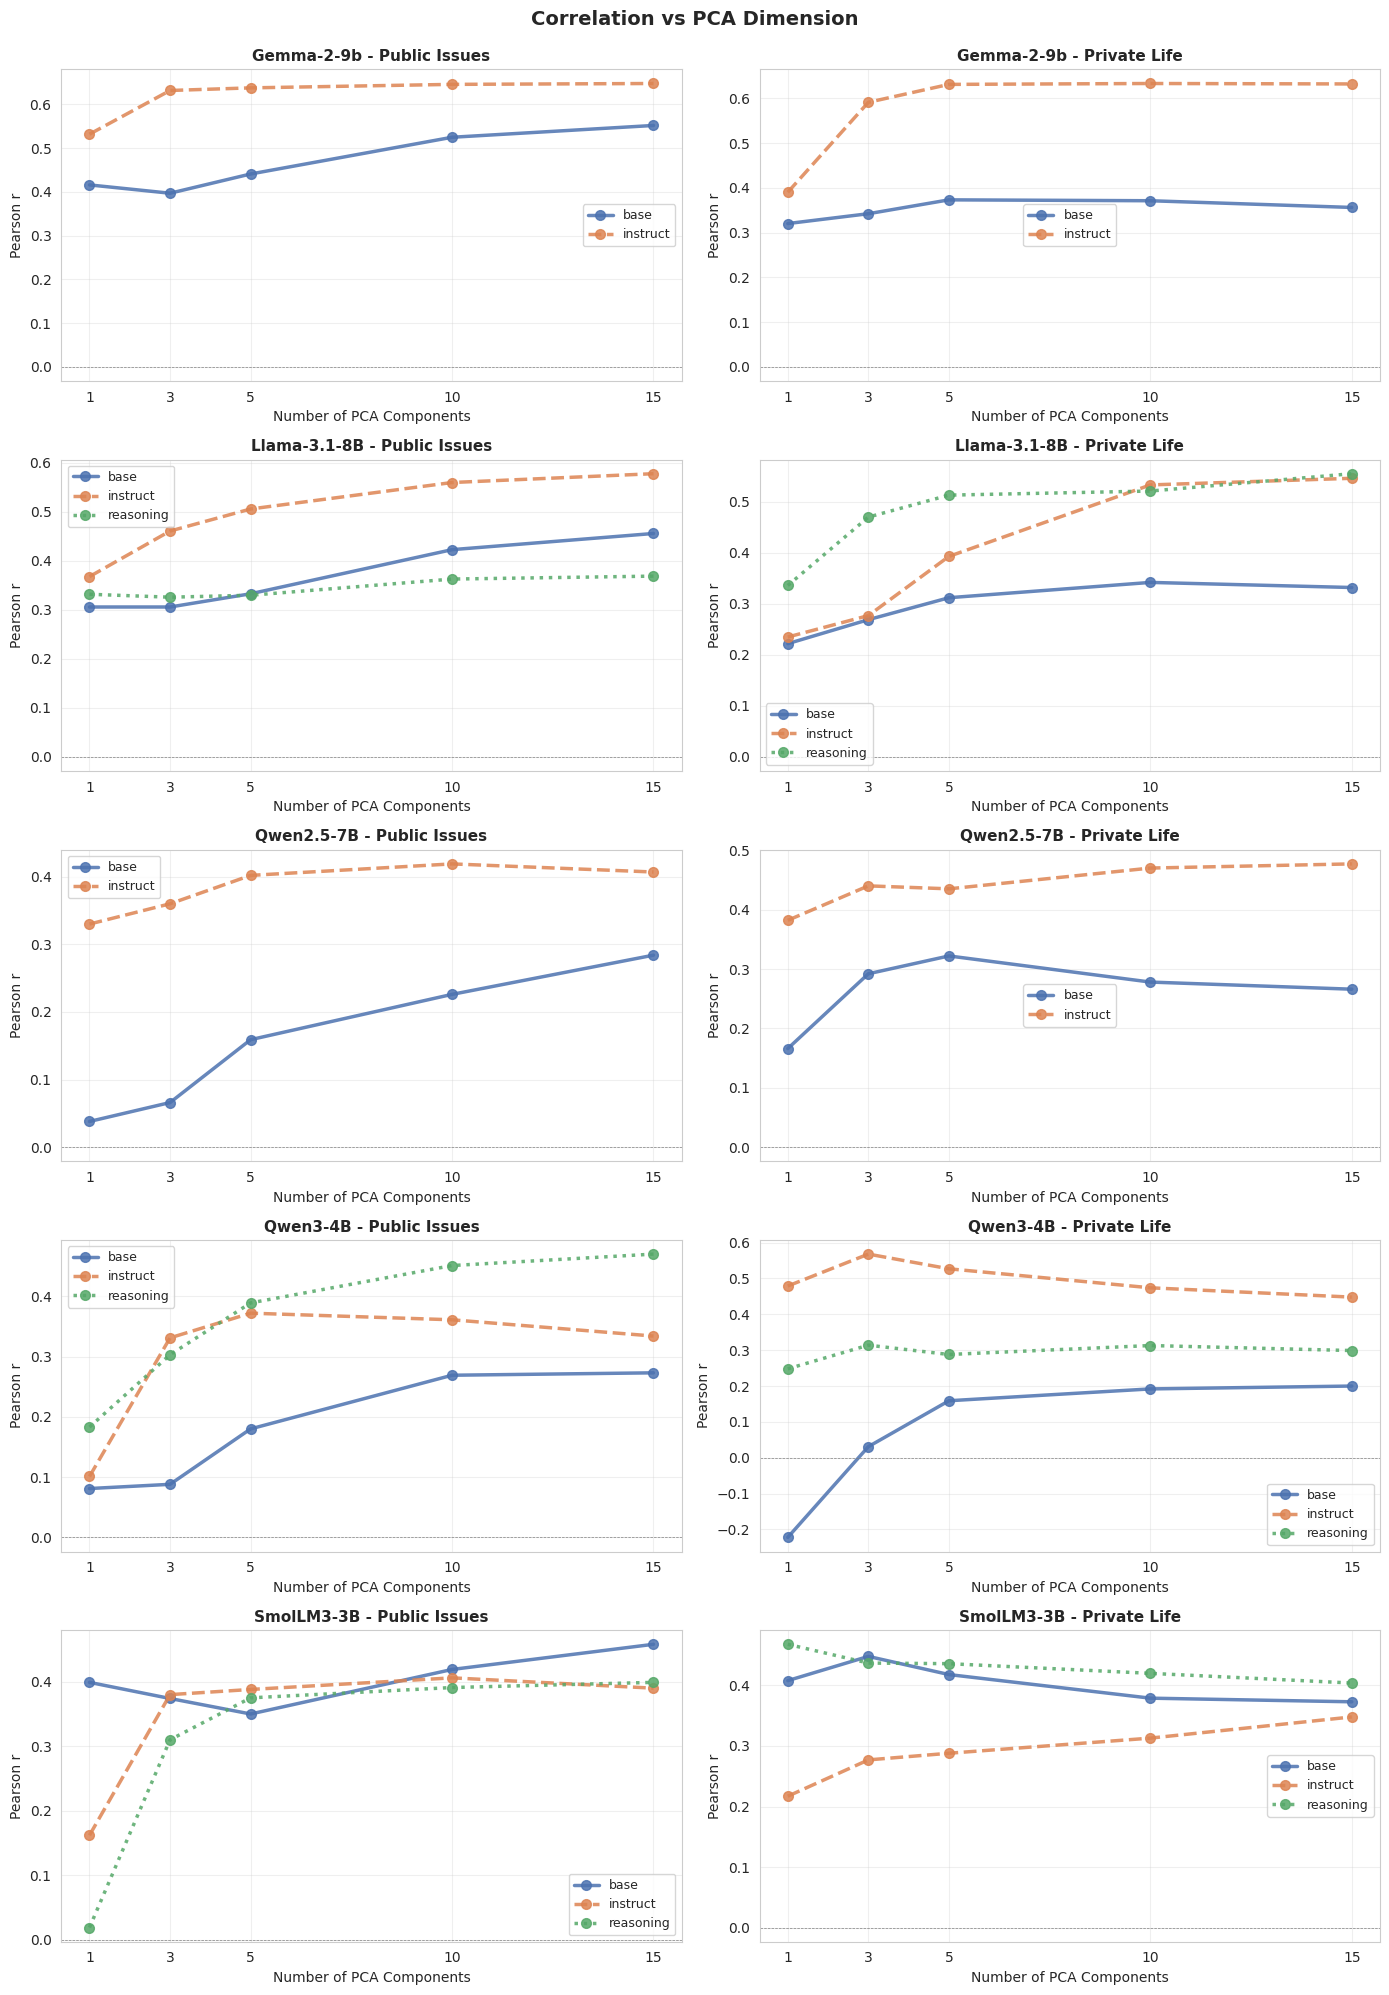

Done!


In [14]:
# Line plot: one side-by-side graph per model family (public issues | private life)
type_colors = {'base': '#4C72B0', 'instruct': '#DD8452', 'reasoning': '#55A868'}
type_linestyles = {'base': '-', 'instruct': '--', 'reasoning': ':'}

# Get unique families
families = sorted(df_pca['family'].unique())
n_families = len(families)

print(f"Plotting {n_families} families...")

# Create subplots: one row per family, two columns (public | private)
fig, axes = plt.subplots(n_families, 2, figsize=(14, 4 * n_families))

# Ensure axes is always 2D
if n_families == 1:
    axes = axes.reshape(1, -1)
elif axes.ndim == 1:
    axes = axes.reshape(-1, 2)

# Plot each family
for family_idx, family_name in enumerate(families):
    print(f"  Family {family_idx + 1}/{n_families}: {family_name}")
    
    df_fam = df_pca[df_pca['family'] == family_name].copy()
    
    # Public issues (left)
    ax_pub = axes[family_idx, 0]
    df_pub = df_fam[df_fam['category'] == 'public_issues']
    
    # Plot each model type within this family
    for model_type in sorted(df_pub['type'].unique()):
        df_type = df_pub[df_pub['type'] == model_type]
        if len(df_type) > 0:
            row = df_type.iloc[0]
            vals = [row[f'PCA{d}'] for d in pca_dims]
            ax_pub.plot(pca_dims, vals, 
                        marker='o', markersize=7,
                        color=type_colors[model_type], 
                        linestyle=type_linestyles[model_type],
                        linewidth=2.5, alpha=0.85, label=model_type)
    
    ax_pub.set_xlabel('Number of PCA Components', fontsize=10)
    ax_pub.set_ylabel('Pearson r', fontsize=10)
    ax_pub.set_title(f'{family_name} - Public Issues', fontsize=11, fontweight='bold')
    ax_pub.set_xticks(pca_dims)
    ax_pub.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax_pub.grid(True, alpha=0.3)
    ax_pub.legend(fontsize=9, loc='best')
    
    # Private life (right)
    ax_priv = axes[family_idx, 1]
    df_priv = df_fam[df_fam['category'] == 'private_life']
    
    # Plot each model type within this family
    for model_type in sorted(df_priv['type'].unique()):
        df_type = df_priv[df_priv['type'] == model_type]
        if len(df_type) > 0:
            row = df_type.iloc[0]
            vals = [row[f'PCA{d}'] for d in pca_dims]
            ax_priv.plot(pca_dims, vals, 
                         marker='o', markersize=7,
                         color=type_colors[model_type], 
                         linestyle=type_linestyles[model_type],
                         linewidth=2.5, alpha=0.85, label=model_type)
    
    ax_priv.set_xlabel('Number of PCA Components', fontsize=10)
    ax_priv.set_ylabel('Pearson r', fontsize=10)
    ax_priv.set_title(f'{family_name} - Private Life', fontsize=11, fontweight='bold')
    ax_priv.set_xticks(pca_dims)
    ax_priv.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax_priv.grid(True, alpha=0.3)
    ax_priv.legend(fontsize=9, loc='best')

fig.suptitle('Correlation vs PCA Dimension', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('../results/comparison_pca_dims_per_family.png', dpi=150, bbox_inches='tight')
plt.show()

print("Done!")

## 9. Error Analysis: Why Ministral Failed

The initial job failed when loading Ministral-3-8B models with:
```
KeyError: 'ministral3'
File ".../transformers/models/auto/configuration_auto.py", line 1048, in __getitem__
    raise KeyError(key)
```

**Root cause:** The installed `transformers` library version doesn't support the Ministral-3 architecture yet. Ministral-3 models were released in December 2024, and support was added in `transformers>=4.48.0`.

**Solution:** A separate sbatch script (`run_model_comparison_missing.sbatch`) has been created to:
1. Upgrade transformers to >=4.48.0
2. Run only the missing families: Ministral-3-8B and Gemma-2-9b

To run:
```bash
sbatch run_model_comparison_missing.sbatch
```

Once complete, re-run this notebook — the data loading cell will automatically detect and combine all checkpoint files.

In [11]:
import transformers
print(f"Current transformers version: {transformers.__version__}")
print(f"Recommended: >= 4.48.0 for Ministral-3 support")

/project/jevans/maxzhuyt/honest_llama_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Current transformers version: 5.1.0
Recommended: >= 4.48.0 for Ministral-3 support
